In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd "/content/drive/MyDrive/Colab Notebooks"

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks


Acurácias em cada fold: [0.94444444 0.88888889 0.88888889 0.94285714 0.91428571]
Acurácia Média: 0.9159
Desvio Padrão: 0.0245


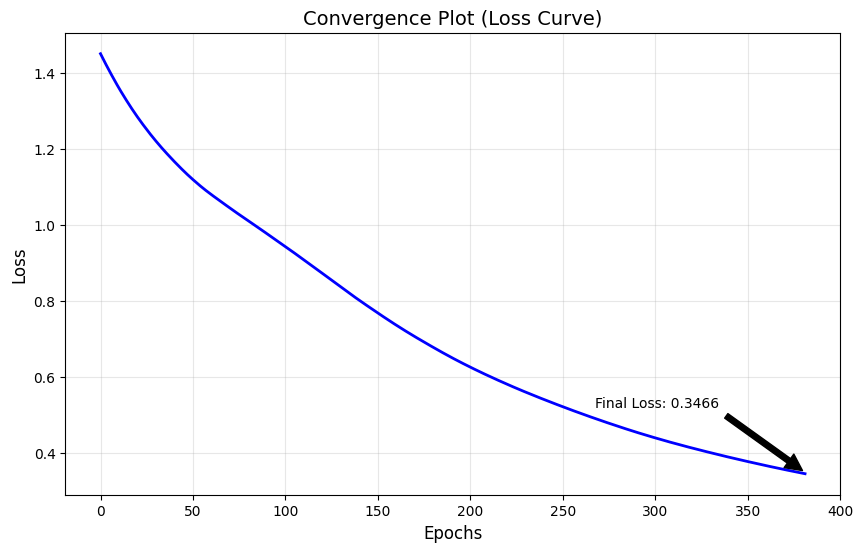

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import cross_val_score, KFold

# ============================================================
# Loading Dataset: it is available as part of sklearn library
# ============================================================
data = load_wine()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# ============================================================
# Pre-processing: scaling and 5-fold cross-validation split
# ============================================================
scaler = MinMaxScaler(feature_range=(-1, 1))
X_scaled = scaler.fit_transform(X)
kf = KFold(n_splits=5, shuffle=True, random_state=42)


# ============================================================
# MLP Model Implementation
#   Topology: 2 hidden layers with 8 and 4 units, respectively
# ============================================================
mlp = MLPClassifier(
    hidden_layer_sizes=(8, 4),
    learning_rate_init=0.001,
    max_iter=2000,
    tol=1e-3,
    random_state=42,
    verbose=False
)

# ============================================================
# Training
# ============================================================
scores = cross_val_score(mlp, X_scaled, y, cv=kf, scoring='accuracy')

# ============================================================
# results
# ============================================================
print(f"Acurácias em cada fold: {scores}")
print(f"Acurácia Média: {scores.mean():.4f}")
print(f"Desvio Padrão: {scores.std():.4f}")

# ============================================================
# CONVERGENCE PLOT (LOSS CURVE)
# ============================================================
mlp.fit(X_scaled, y)

plt.figure(figsize=(10, 6))
plt.plot(mlp.loss_curve_, color='blue', lw=2)
plt.title('Convergence Plot (Loss Curve)', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, alpha=0.3)

plt.annotate(f'Final Loss: {mlp.loss_:.4f}',
             xy=(len(mlp.loss_curve_), mlp.loss_),
             xytext=(len(mlp.loss_curve_)*0.7, mlp.loss_*1.5),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()


